In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [52]:
df=pd.read_csv('health_data.csv')
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589980e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262960e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679510e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841190e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [53]:
df.shape

(110527, 14)

In [54]:
df.describe()

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.920000e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172615e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173180e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439170e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999820e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


In [56]:
df.isna().sum()

PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64

In [57]:
df.isnull().sum()

PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64

In [58]:
df[df["Age"]<0]

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
99832,4.659430e+14,5775010,F,2016-06-06T08:58:13Z,2016-06-06T00:00:00Z,-1,ROMÃO,0,0,0,0,0,0,No


there is only one row , lets delete it

In [59]:
d=df[df['Age']<0].index
df.drop(d,inplace=True)
df[df['Age']<0]


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show


In [60]:
df.rename(columns={"Hipertension":"Hypertension","No-show":"No"},inplace=True)
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hypertension,Diabetes,Alcoholism,Handcap,SMS_received,No
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589980e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262960e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679510e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841190e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [61]:
df.drop_duplicates(['PatientId', 'No'], inplace=True)

In [62]:
df.drop(['PatientId', 'AppointmentID', 'ScheduledDay', 'AppointmentDay'], axis=1, inplace=True)
df.head()

,Gender,Age,Neighbourhood,Scholarship,Hypertension,Diabetes,Alcoholism,Handcap,SMS_received,No
0,F,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,M,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,F,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,F,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,F,56,JARDIM DA PENHA,0,1,1,0,0,0,No


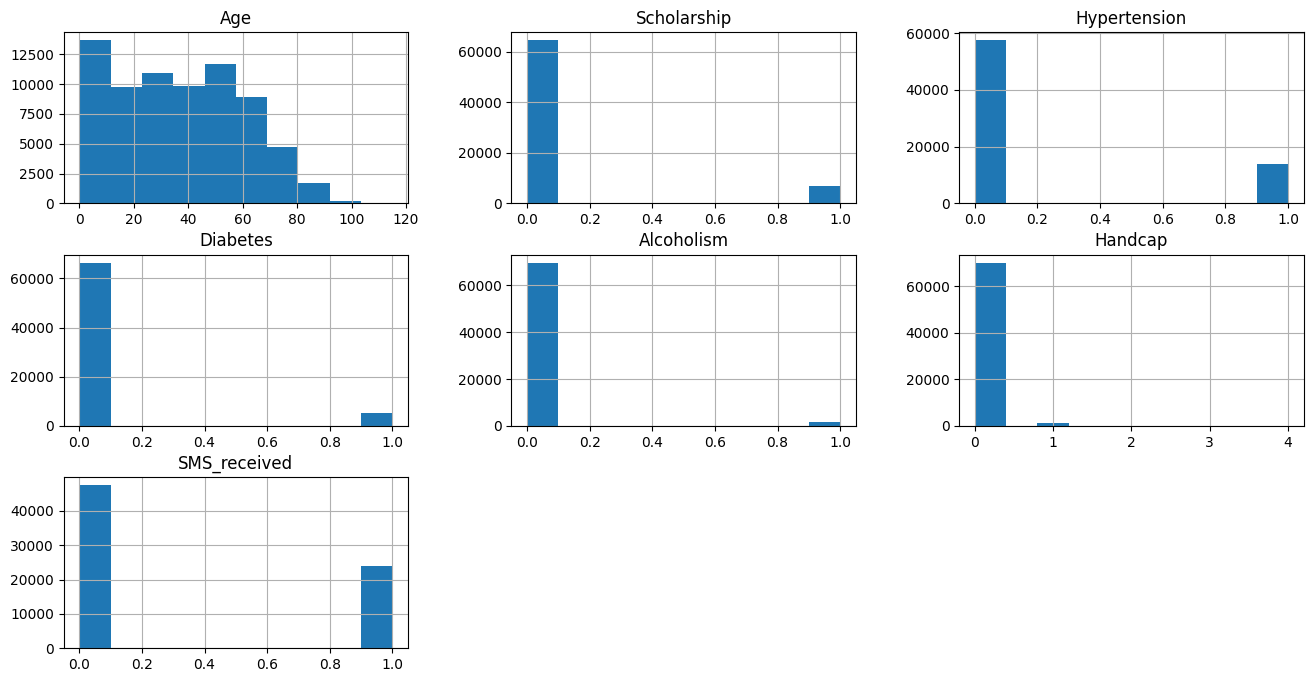

In [63]:
df.hist(figsize=(16, 8), )
plt.show()

this shows that most of the people are aged between 0 to 60 
majority does not has scholarship, hypertension,diabetes, alcoholism and handcap
majority of them have not received SMS


In [64]:
show = df.No == 'No'
noshow = df.No == 'Yes'

In [65]:
len(df[show]), len(df[noshow])

(53730, 17622)

In [66]:
def attendance(df, col_name, attended, absent):
    plt.figure(figsize=[16, 4])
    df[col_name][show].hist(alpha=.5, bins=10, color='blue', label='show')
    df[col_name][noshow].hist(alpha=.5, bins=10, color='cyan', label='noshow')
    plt.legend();
    plt.title(f'Comparison Acc. to {col_name}')
    plt.xlabel(f'{col_name}')
    plt.ylabel('Patients Number')

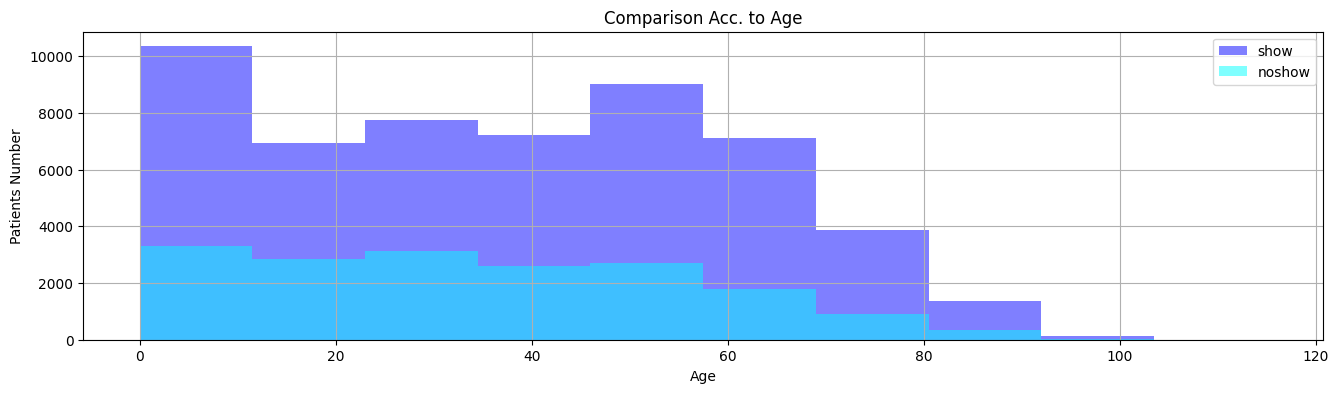

In [67]:
attendance(df,'Age', show, noshow)

Text(0, 0.5, 'Patients Number')

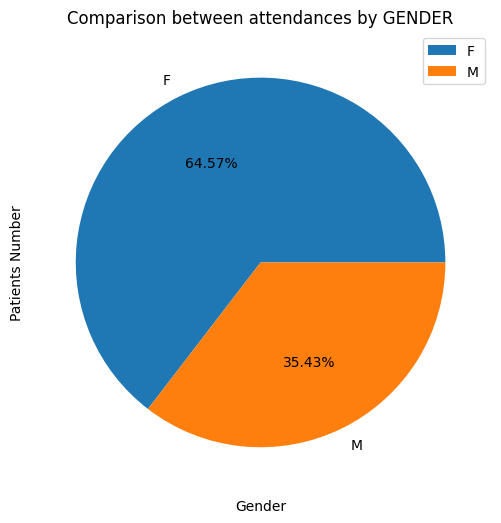

In [68]:
plt.figure(figsize=[16, 6])
df["Gender"][show].value_counts(normalize=True).plot(kind='pie',label='Show', autopct='%.2f%%')
plt.legend()
plt.title('Comparison between attendances by GENDER')
plt.xlabel('Gender')
plt.ylabel('Patients Number')


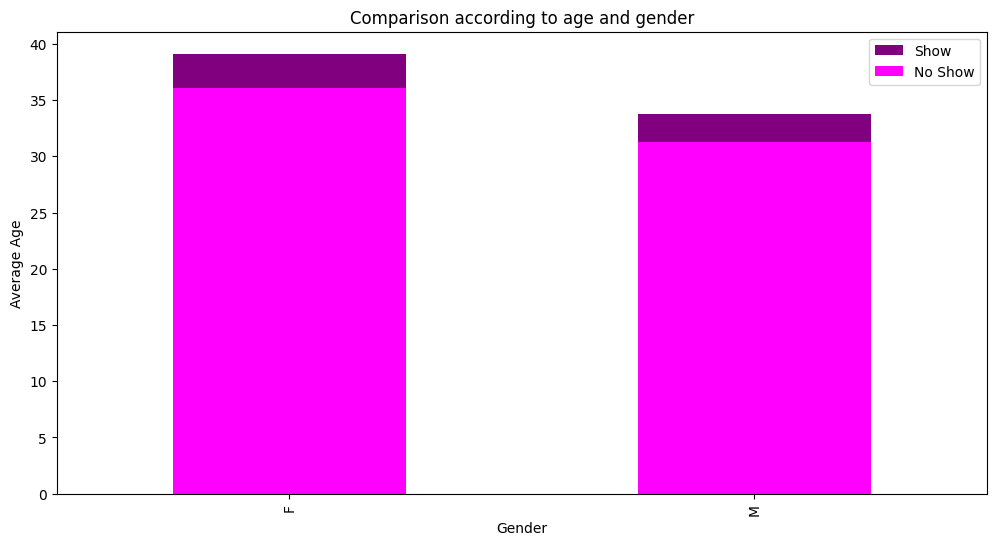

In [69]:
plt.figure(figsize=[12,6])
df[show].groupby('Gender').Age.mean().plot(kind='bar', color='purple', label='Show')
df[noshow].groupby('Gender').Age.mean().plot(kind='bar', color='magenta', label='No Show')
plt.legend()
plt.title('Comparison according to age and gender')
plt.xlabel("Gender")
plt.ylabel("Average Age")
plt.show()

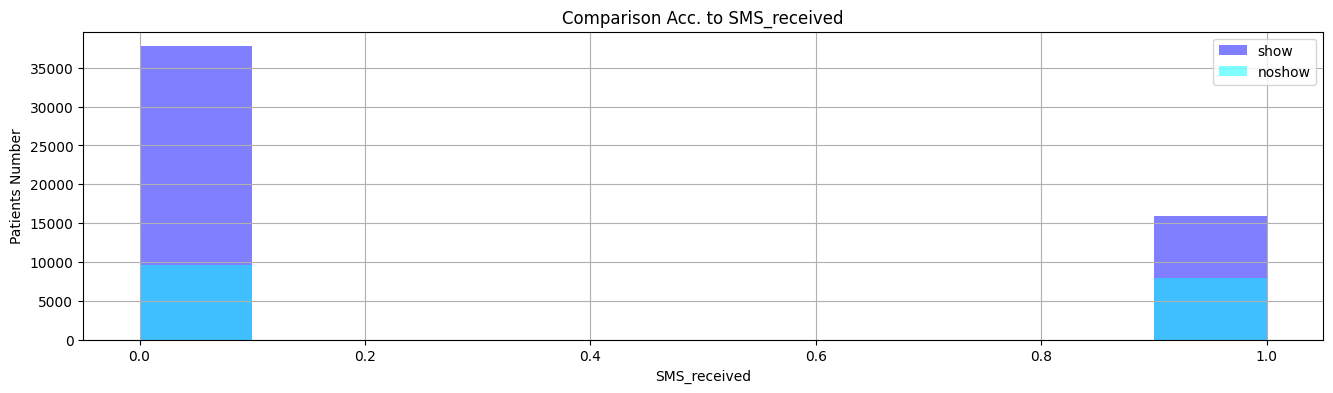

In [70]:
attendance(df,'SMS_received', show, noshow)

Text(0, 0.5, 'Patients Number')

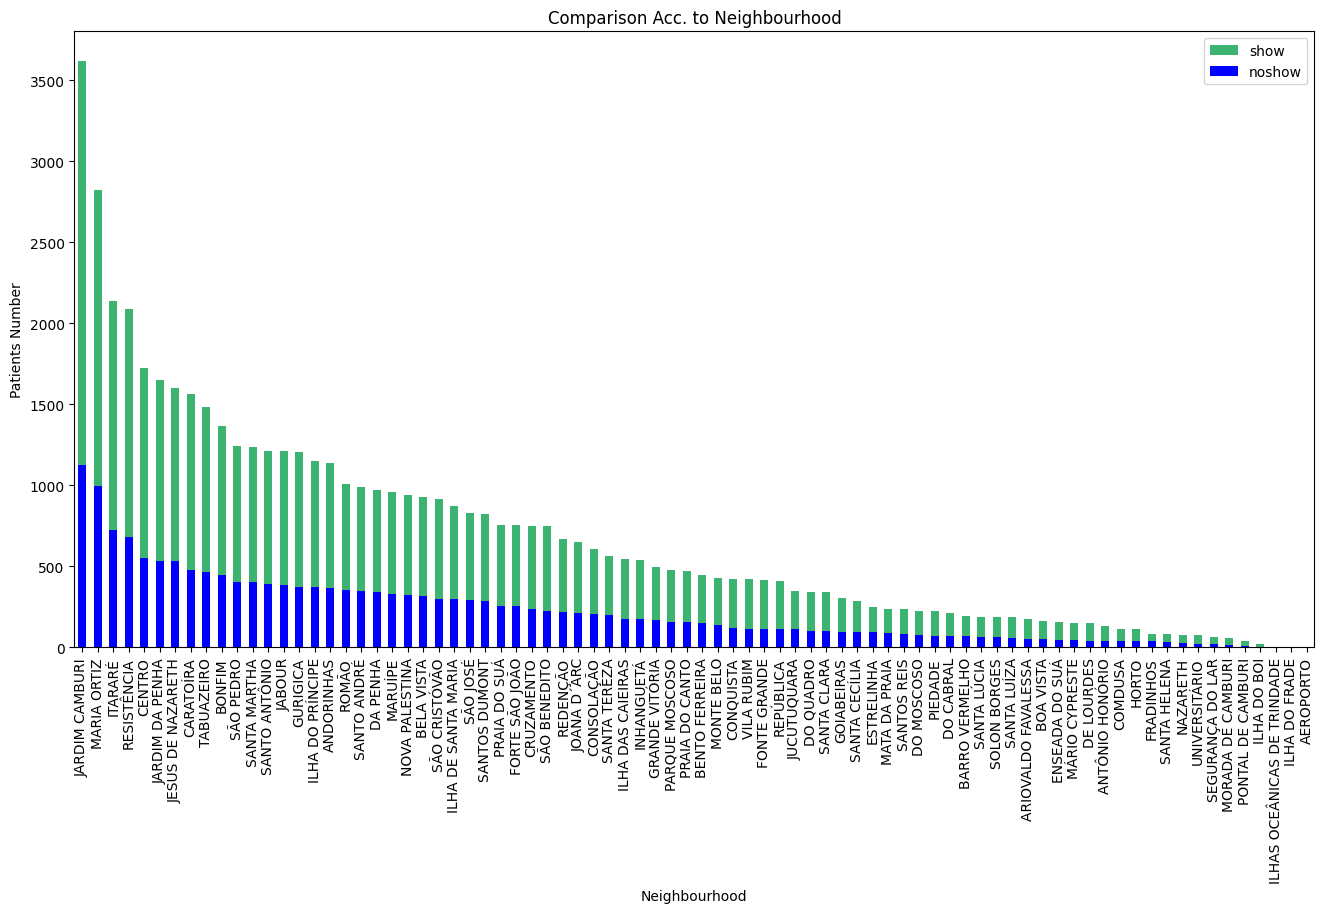

In [77]:
plt.figure(figsize=(16, 8))
df.Neighbourhood[show].value_counts().plot(kind='bar', color='mediumseagreen', label='show')
df.Neighbourhood[noshow].value_counts().plot(kind='bar', color='blue', label='noshow')
plt.legend();
plt.title('Comparison Acc. to Neighbourhood')
plt.xlabel('Neighbourhood')
plt.ylabel('Patients Number')

In [78]:
df.columns

Index(['Gender', 'Age', 'Neighbourhood', 'Scholarship', 'Hypertension',
       'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No'],
      dtype='object')

Text(0, 0.5, 'Patients Number')

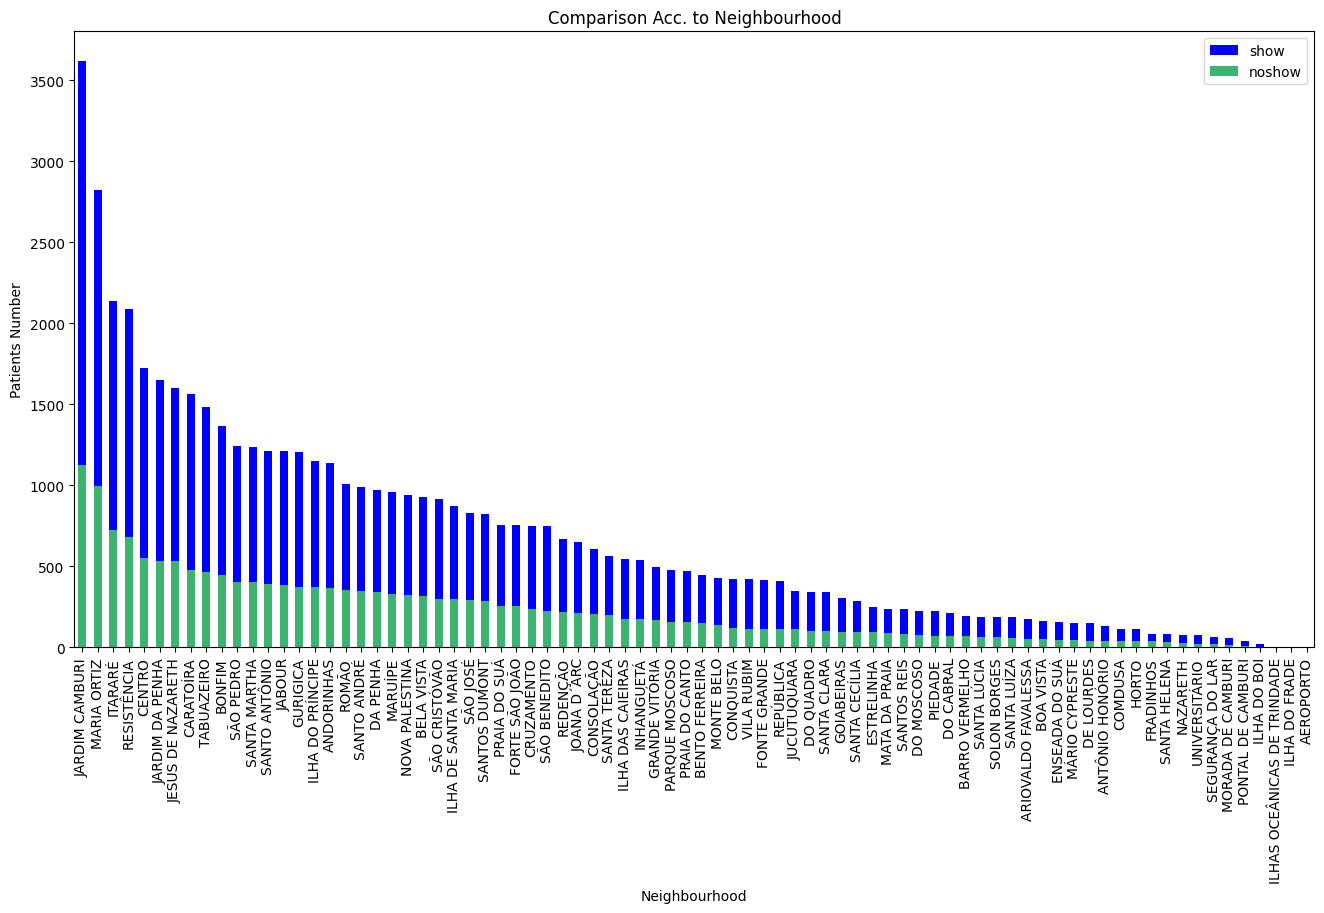

In [79]:
plt.figure(figsize=[16, 8]) 
df.Neighbourhood[show].value_counts().plot(kind='bar', color='blue', label='show')
df.Neighbourhood[noshow].value_counts().plot(kind='bar', color='mediumseagreen', label='noshow')
plt.legend();
plt.title('Comparison Acc. to Neighbourhood')
plt.xlabel('Neighbourhood')
plt.ylabel('Patients Number')

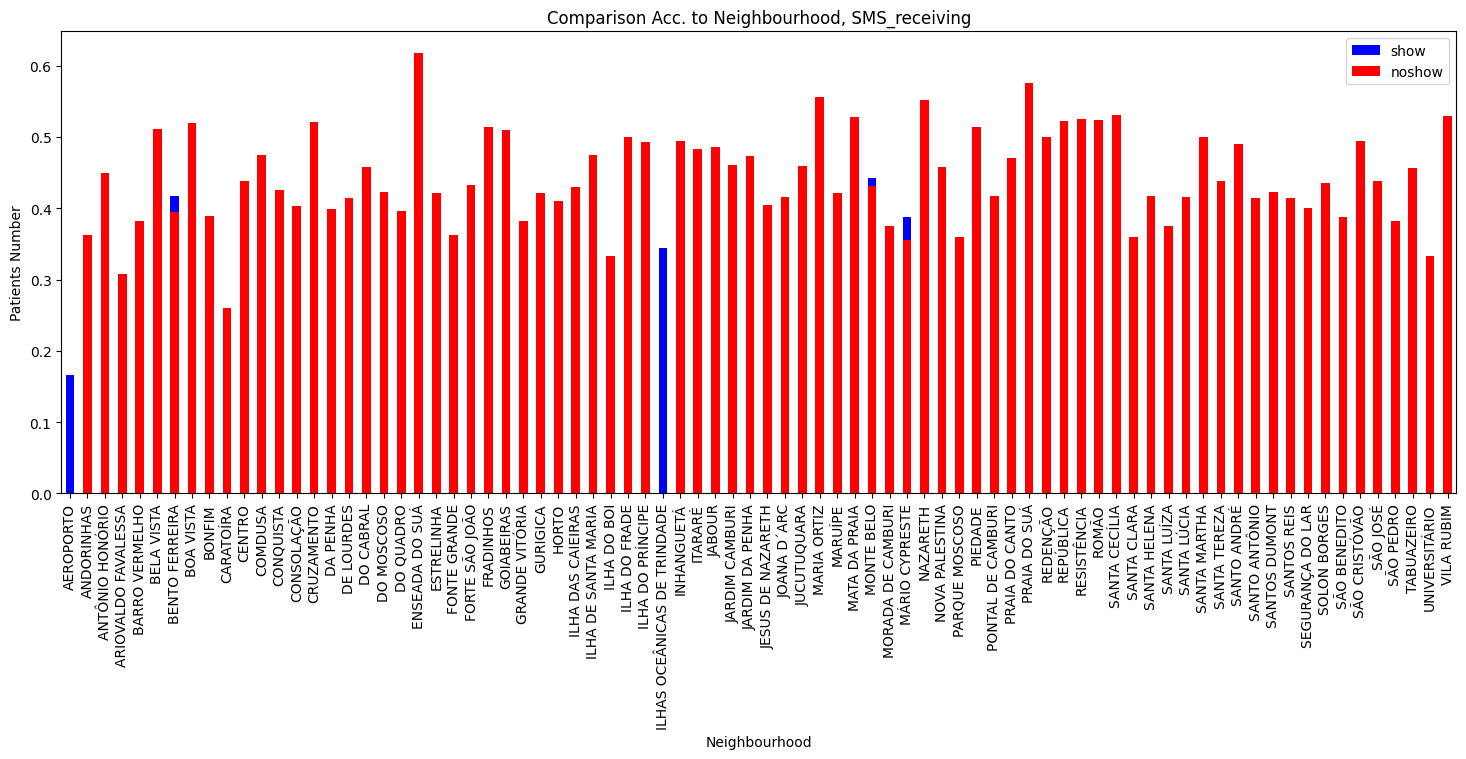

In [80]:
plt.figure(figsize=(18, 6))
df[show].groupby('Neighbourhood').SMS_received.mean().plot(kind='bar', color='blue', label='show')
df[noshow].groupby('Neighbourhood').SMS_received.mean().plot(kind='bar', color='red', label='noshow')
plt.legend()
plt.title('Comparison Acc. to Neighbourhood, SMS_receiving')
plt.xlabel('Neighbourhood')
plt.ylabel('Patients Number')
plt.show()